Found 18 rough peaks at channel indices: [ 22  42  62  83 120 140 171 195 229 259 280 307 339 390 448 472 499 859]
Corresponding to rough voltages: [0.19960696 0.24284692 0.28608688 0.33148884 0.41148276 0.45472273
 0.52174467 0.57363262 0.64714055 0.71200049 0.75740245 0.8157764
 0.88496034 0.99522224 1.12061812 1.17250608 1.23088002 2.00919932]
Peak near 0.200 V: Exact Centroid = 0.2007 V
Peak near 0.243 V: Exact Centroid = 0.2299 V
Peak near 0.286 V: Exact Centroid = 0.2851 V
Peak near 0.331 V: Exact Centroid = 0.3283 V
Peak near 0.411 V: Exact Centroid = 0.4133 V
Peak near 0.455 V: Exact Centroid = 0.4397 V
Peak near 0.522 V: Exact Centroid = 0.5217 V
Peak near 0.574 V: Exact Centroid = 0.5715 V
Peak near 0.647 V: Exact Centroid = 0.6482 V
Peak near 0.712 V: Exact Centroid = 0.7011 V
Peak near 0.757 V: Exact Centroid = 0.7537 V
Peak near 0.816 V: Exact Centroid = 0.8312 V
Peak near 0.885 V: Exact Centroid = 0.8795 V
Peak near 0.995 V: Exact Centroid = 0.9937 V
Peak near 1.121 V: Ex

C:\Users\Berkeley\AppData\Local\Temp\ipykernel_16236\2676025363.py:69: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=p0)


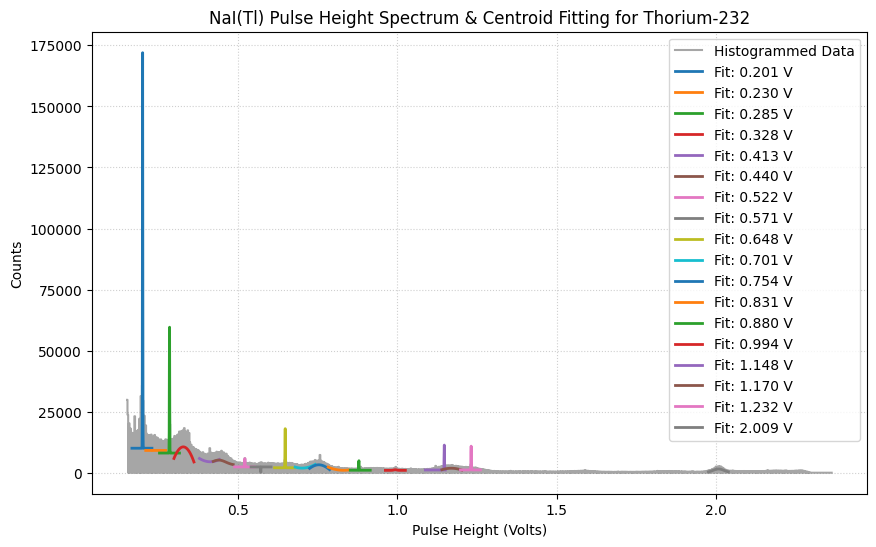


Final Exact Voltages for Calibration:
[0.20065032 0.2298742  0.28511804 0.32832606 0.41328712 0.43974733
 0.5217111  0.57147369 0.64816695 0.70112245 0.75370539 0.83120366
 0.87954496 0.9937491  1.14764426 1.16963749 1.23185817 2.00855311]


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

# ==========================================
# 1. Define the Gaussian Function
# ==========================================
def gaussian(x, amplitude, centroid, sigma, background):
    return amplitude * np.exp(-((x - centroid) ** 2) / (2 * sigma ** 2)) + background

# ==========================================
# 2. Load and Histogram the Pulse Heights
# ==========================================
# Load your single-column CSV
df = pd.read_csv('111_source_overnight_100MHz.csv')
voltages = df['pulse_height_V'].values

# Define your "channels" by binning the voltage data
# 1024 channels is standard, but you can change this to 2048 or 4096 if needed
num_channels = 1024 

# np.histogram counts how many pulses fall into each voltage bucket (channel)
counts, bin_edges = np.histogram(voltages, bins=num_channels)

# Calculate the center of each bin to serve as our X-axis (in Volts)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Create a simple integer channel array (0 to 1023) for tracking indices
channels = np.arange(num_channels)

# ==========================================
# 3. Find Rough Peaks
# ==========================================
# Note: Because we are looking at the histogrammed 'counts', 
# adjust height/prominence based on your total data size.
# WILL NEED TO TUNE THESE PARAMETERS
rough_peak_indices, _ = find_peaks(counts, height=2000, distance=20, prominence=30)

print(f"Found {len(rough_peak_indices)} rough peaks at channel indices: {rough_peak_indices}")
print(f"Corresponding to rough voltages: {bin_centers[rough_peak_indices]}")

# ==========================================
# 4. Centroid Fitting (Using Voltage as the X-axis)
# ==========================================
exact_voltage_centroids = []
fit_window = 15 # Number of bins to check on either side of the peak

plt.figure(figsize=(10, 6))
plt.step(bin_centers, counts, where='mid', label='Histogrammed Data', color='gray', alpha=0.7)

for p_idx in rough_peak_indices:
    # Slice the data around the peak index
    start = max(0, p_idx - fit_window)
    end = min(num_channels, p_idx + fit_window)
    
    x_fit = bin_centers[start:end]
    y_fit = counts[start:end]
    
    # Initial guesses using the actual voltage scale
    guess_amp = counts[p_idx] - np.min(y_fit)
    guess_centroid = bin_centers[p_idx]
    guess_sigma = (bin_centers[1] - bin_centers[0]) * 3.0 # Guess width of 3 bins
    guess_bg = np.min(y_fit)
    p0 = [guess_amp, guess_centroid, guess_sigma, guess_bg]
    
    try:
        popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=p0)
        fitted_voltage = popt[1]
        exact_voltage_centroids.append(fitted_voltage)
        
        print(f"Peak near {bin_centers[p_idx]:.3f} V: Exact Centroid = {fitted_voltage:.4f} V")
        
        # Plot the fitted curve
        x_plot = np.linspace(x_fit[0], x_fit[-1], 100)
        plt.plot(x_plot, gaussian(x_plot, *popt), label=f'Fit: {fitted_voltage:.3f} V', linewidth=2)
        
    except RuntimeError:
        print(f"Fit failed for peak at index {p_idx}.")

# ==========================================
# 5. Visualize
# ==========================================
plt.title('NaI(Tl) Pulse Height Spectrum & Centroid Fitting for Thorium-232')
plt.xlabel('Pulse Height (Volts)')
plt.ylabel('Counts')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# ==========================================
# 6. Next Steps: Energy Calibration
# ==========================================
print("\nFinal Exact Voltages for Calibration:")
print(np.array(exact_voltage_centroids))

Found 15 rough peaks at channel indices: [ 23  44  81 138 172 207 229 280 363 390 463 499 664 859 979]
Corresponding to rough voltages: [0.20176895 0.24717091 0.32716484 0.45039873 0.52390666 0.59957659
 0.64714055 0.75740245 0.93684829 0.99522224 1.15304809 1.23088002
 1.5876097  2.00919932 2.26863909]
Peak near 0.202 V: Exact Centroid = 0.1998 V
Peak near 0.247 V: Exact Centroid = 0.2410 V
Peak near 0.327 V: Exact Centroid = 0.3193 V
Peak near 0.450 V: Exact Centroid = 0.4423 V
Peak near 0.524 V: Exact Centroid = 0.5542 V
Peak near 0.600 V: Exact Centroid = 0.5982 V
Peak near 0.647 V: Exact Centroid = 0.6494 V
Peak near 0.757 V: Exact Centroid = 0.7533 V
Peak near 0.937 V: Exact Centroid = 0.9044 V
Peak near 0.995 V: Exact Centroid = 0.9643 V
Peak near 1.153 V: Exact Centroid = 1.1680 V
Peak near 1.231 V: Exact Centroid = 1.2254 V
Peak near 1.588 V: Exact Centroid = 1.5847 V
Peak near 2.009 V: Exact Centroid = 2.0086 V
Peak near 2.269 V: Exact Centroid = 2.2572 V


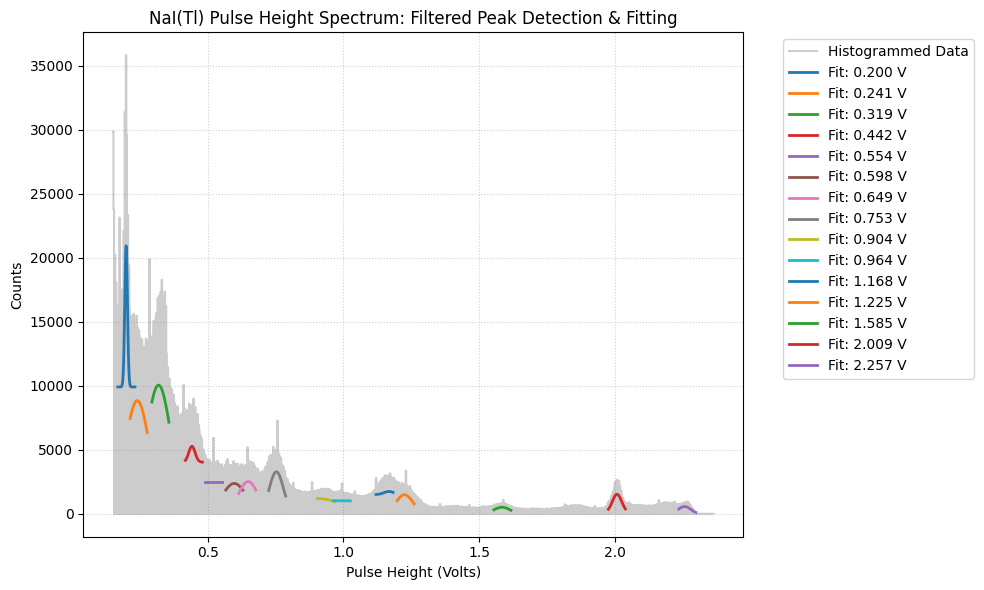


Final Exact Voltages for Calibration:
[0.19976382 0.2409764  0.31930258 0.4422669  0.55417464 0.59820249
 0.64937717 0.75332598 0.90441832 0.96428487 1.16798175 1.22542718
 1.58471414 2.008553   2.25716363]


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, butter, filtfilt
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter1d

# ==========================================
# 1. Define the Functions
# ==========================================
def gaussian(x, amplitude, centroid, sigma, background):
    return amplitude * np.exp(-((x - centroid) ** 2) / (2 * sigma ** 2)) + background

def butter_bandpass_filter(data, lowcut, highcut, fs, order=3):
    """
    Applies a zero-phase Butterworth bandpass filter.
    Note: 'fs' here represents the sampling rate of our bins (e.g., 1 bin = 1 sample).
    """
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

# ==========================================
# 2. Load and Histogram the Pulse Heights
# ==========================================
# Load your single-column CSV
df = pd.read_csv('111_source_overnight_100MHz.csv')
voltages = df['pulse_height_V'].values

# Define your channels
num_channels = 1024 
counts, bin_edges = np.histogram(voltages, bins=num_channels)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# ==========================================
# 3. Filter Data and Find Rough Peaks
# ==========================================
# 3a. Bandpass Filter (Removes global baseline drift and high-frequency noise)
# Tuning parameters: fs=1.0 (1 sample per bin). 
# Lowcut > 0 removes the broad continuum; Highcut < 0.5 removes sharp noise.
filtered_counts = butter_bandpass_filter(counts, lowcut=0.01, highcut=0.2, fs=1.0, order=3)

# 3b. Gaussian Filter (Further smooths the remaining signal for peak detection)
smoothed_counts = gaussian_filter1d(filtered_counts, sigma=3)

# 3c. Find peaks on the FILTERED data
# (Note: Prominence and height thresholds might need to be lowered since 
# filtering removes the baseline amplitude)
rough_peak_indices, _ = find_peaks(smoothed_counts, height=100, distance=20, prominence=20)

print(f"Found {len(rough_peak_indices)} rough peaks at channel indices: {rough_peak_indices}")
print(f"Corresponding to rough voltages: {bin_centers[rough_peak_indices]}")

# ==========================================
# 4. Centroid Fitting (Using Raw Data)
# ==========================================
exact_voltage_centroids = []
fit_window = 15 # Number of bins to check on either side of the peak

plt.figure(figsize=(10, 6))
# Plot raw data in background
plt.step(bin_centers, counts, where='mid', label='Histogrammed Data', color='gray', alpha=0.4)

# Optional: Plot the filtered data so you can see what the peak-finder is looking at
# plt.plot(bin_centers, smoothed_counts, label='Bandpass + Gaussian Filtered', color='blue', alpha=0.3)

for p_idx in rough_peak_indices:
    # Slice the RAW data around the peak index for accurate fitting
    start = max(0, p_idx - fit_window)
    end = min(num_channels, p_idx + fit_window)
    
    x_fit = bin_centers[start:end]
    y_fit = counts[start:end]
    
    # Initial guesses
    guess_amp = counts[p_idx] - np.min(y_fit)
    guess_centroid = bin_centers[p_idx]
    guess_sigma = (bin_centers[1] - bin_centers[0]) * 3.0 # Guess width of 3 bins
    guess_bg = np.min(y_fit)
    p0 = [guess_amp, guess_centroid, guess_sigma, guess_bg]
    
    # Constrain the optimizer so it doesn't fit to single-bin noise spikes
    # Bounds: [amplitude, centroid, sigma, background]
    lower_bounds = [0, x_fit[0], 0.005, 0] 
    upper_bounds = [np.inf, x_fit[-1], 0.5, np.inf]
    
    try:
        popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=p0, bounds=(lower_bounds, upper_bounds))
        fitted_voltage = popt[1]
        exact_voltage_centroids.append(fitted_voltage)
        
        print(f"Peak near {bin_centers[p_idx]:.3f} V: Exact Centroid = {fitted_voltage:.4f} V")
        
        # Plot the fitted curve over the raw data
        x_plot = np.linspace(x_fit[0], x_fit[-1], 100)
        plt.plot(x_plot, gaussian(x_plot, *popt), label=f'Fit: {fitted_voltage:.3f} V', linewidth=2)
        
    except RuntimeError:
        print(f"Fit failed for peak at index {p_idx}.")

# ==========================================
# 5. Visualize
# ==========================================
plt.title('NaI(Tl) Pulse Height Spectrum: Filtered Peak Detection & Fitting')
plt.xlabel('Pulse Height (Volts)')
plt.ylabel('Counts')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Moved legend outside plot to avoid clutter
plt.tight_layout()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# ==========================================
# 6. Next Steps: Energy Calibration
# ==========================================
print("\nFinal Exact Voltages for Calibration:")
print(np.array(exact_voltage_centroids))

Found 7 rough peaks at channel indices: [ 62 148 173 232 718 798 863]
Corresponding to rough voltages: [0.28541458 0.47042132 0.52420235 0.65112558 1.69662881 1.86872811
 2.00855879]
Peak near 0.285 V: Exact Centroid = 0.2580 V
Peak near 0.470 V: Exact Centroid = 0.4382 V
Peak near 0.524 V: Exact Centroid = 0.4972 V
Peak near 0.651 V: Exact Centroid = 0.6485 V
Peak near 1.697 V: Exact Centroid = 1.6644 V
Peak near 1.869 V: Exact Centroid = 1.8509 V
Peak near 2.009 V: Exact Centroid = 1.9942 V


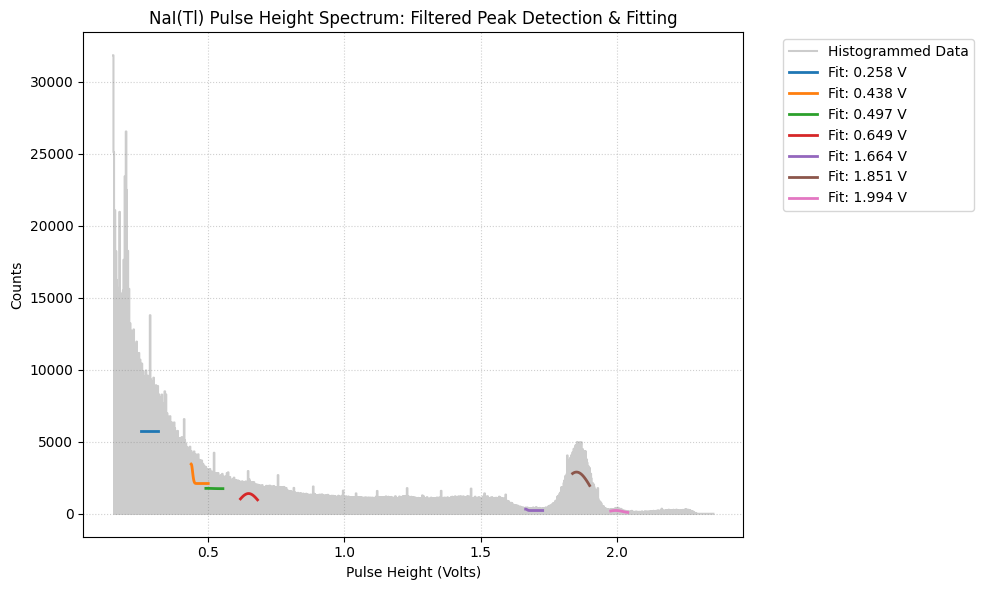


Final Exact Voltages for Calibration:
[0.25797211 0.4381527  0.49720336 0.64851425 1.66436019 1.85085052
 1.99419094]


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, butter, filtfilt
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter1d

# ==========================================
# 1. Define the Functions
# ==========================================
def gaussian(x, amplitude, centroid, sigma, background):
    return amplitude * np.exp(-((x - centroid) ** 2) / (2 * sigma ** 2)) + background

def butter_bandpass_filter(data, lowcut, highcut, fs, order=3):
    """
    Applies a zero-phase Butterworth bandpass filter.
    Note: 'fs' here represents the sampling rate of our bins (e.g., 1 bin = 1 sample).
    """
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

# ==========================================
# 2. Load and Histogram the Pulse Heights
# ==========================================
# Load your single-column CSV
df = pd.read_csv('111_KCl_overnight.csv')
voltages = df['pulse_height_V'].values

# Define your channels
num_channels = 1024 
counts, bin_edges = np.histogram(voltages, bins=num_channels)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# ==========================================
# 3. Filter Data and Find Rough Peaks
# ==========================================
# 3a. Bandpass Filter (Removes global baseline drift and high-frequency noise)
# Tuning parameters: fs=1.0 (1 sample per bin). 
# Lowcut > 0 removes the broad continuum; Highcut < 0.5 removes sharp noise.
filtered_counts = butter_bandpass_filter(counts, lowcut=0.01, highcut=0.2, fs=1.0, order=3)

# 3b. Gaussian Filter (Further smooths the remaining signal for peak detection)
smoothed_counts = gaussian_filter1d(filtered_counts, sigma=3)

# 3c. Find peaks on the FILTERED data
# (Note: Prominence and height thresholds might need to be lowered since 
# filtering removes the baseline amplitude)
rough_peak_indices, _ = find_peaks(smoothed_counts, height=100, distance=20, prominence=20)

print(f"Found {len(rough_peak_indices)} rough peaks at channel indices: {rough_peak_indices}")
print(f"Corresponding to rough voltages: {bin_centers[rough_peak_indices]}")

# ==========================================
# 4. Centroid Fitting (Using Raw Data)
# ==========================================
exact_voltage_centroids = []
fit_window = 15 # Number of bins to check on either side of the peak

plt.figure(figsize=(10, 6))
# Plot raw data in background
plt.step(bin_centers, counts, where='mid', label='Histogrammed Data', color='gray', alpha=0.4)

# Optional: Plot the filtered data so you can see what the peak-finder is looking at
# plt.plot(bin_centers, smoothed_counts, label='Bandpass + Gaussian Filtered', color='blue', alpha=0.3)

for p_idx in rough_peak_indices:
    # Slice the RAW data around the peak index for accurate fitting
    start = max(0, p_idx - fit_window)
    end = min(num_channels, p_idx + fit_window)
    
    x_fit = bin_centers[start:end]
    y_fit = counts[start:end]
    
    # Initial guesses
    guess_amp = counts[p_idx] - np.min(y_fit)
    guess_centroid = bin_centers[p_idx]
    guess_sigma = (bin_centers[1] - bin_centers[0]) * 3.0 # Guess width of 3 bins
    guess_bg = np.min(y_fit)
    p0 = [guess_amp, guess_centroid, guess_sigma, guess_bg]
    
    # Constrain the optimizer so it doesn't fit to single-bin noise spikes
    # Bounds: [amplitude, centroid, sigma, background]
    lower_bounds = [0, x_fit[0], 0.005, 0] 
    upper_bounds = [np.inf, x_fit[-1], 0.5, np.inf]
    
    try:
        popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=p0, bounds=(lower_bounds, upper_bounds))
        fitted_voltage = popt[1]
        exact_voltage_centroids.append(fitted_voltage)
        
        print(f"Peak near {bin_centers[p_idx]:.3f} V: Exact Centroid = {fitted_voltage:.4f} V")
        
        # Plot the fitted curve over the raw data
        x_plot = np.linspace(x_fit[0], x_fit[-1], 100)
        plt.plot(x_plot, gaussian(x_plot, *popt), label=f'Fit: {fitted_voltage:.3f} V', linewidth=2)
        
    except RuntimeError:
        print(f"Fit failed for peak at index {p_idx}.")

# ==========================================
# 5. Visualize
# ==========================================
plt.title('NaI(Tl) Pulse Height Spectrum: Filtered Peak Detection & Fitting')
plt.xlabel('Pulse Height (Volts)')
plt.ylabel('Counts')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Moved legend outside plot to avoid clutter
plt.tight_layout()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# ==========================================
# 6. Next Steps: Energy Calibration
# ==========================================
print("\nFinal Exact Voltages for Calibration:")
print(np.array(exact_voltage_centroids))

Found 4 rough peaks at channel indices: [  5  56 138 164]
Corresponding to rough voltages: [0.19671173 0.6209365  1.30302339 1.51929485]
Peak near 0.197 V: Exact Centroid = 0.1977 V
Peak near 0.621 V: Exact Centroid = 0.4962 V
Peak near 1.303 V: Exact Centroid = 1.3069 V
Peak near 1.519 V: Exact Centroid = 1.5093 V


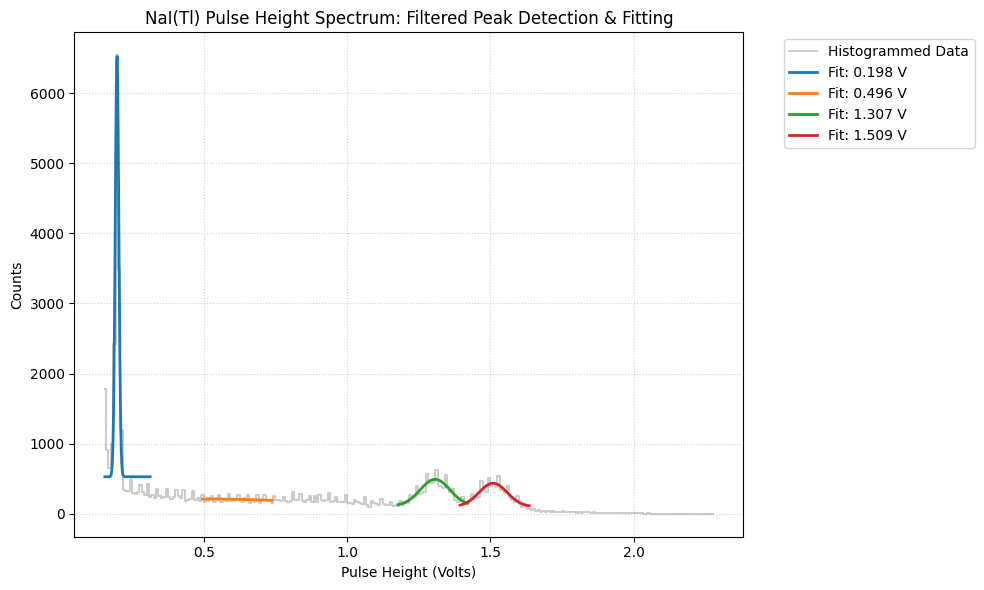


Final Exact Voltages for Calibration:
[0.19771493 0.49616451 1.30693846 1.50929727]


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, butter, filtfilt
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter1d

# ==========================================
# 1. Define the Functions
# ==========================================
def gaussian(x, amplitude, centroid, sigma, background):
    return amplitude * np.exp(-((x - centroid) ** 2) / (2 * sigma ** 2)) + background

def butter_bandpass_filter(data, lowcut, highcut, fs, order=3):
    """
    Applies a zero-phase Butterworth bandpass filter.
    Note: 'fs' here represents the sampling rate of our bins (e.g., 1 bin = 1 sample).
    """
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

# ==========================================
# 2. Load and Histogram the Pulse Heights
# ==========================================
# Load your single-column CSV
df = pd.read_csv('Co60_30min.csv')
voltages = df['pulse_height_V'].values

# Define your channels
num_channels = 256 
counts, bin_edges = np.histogram(voltages, bins=num_channels)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# ==========================================
# 3. Filter Data and Find Rough Peaks
# ==========================================
# 3a. Bandpass Filter (Removes global baseline drift and high-frequency noise)
# Tuning parameters: fs=1.0 (1 sample per bin). 
# Lowcut > 0 removes the broad continuum; Highcut < 0.5 removes sharp noise.
filtered_counts = butter_bandpass_filter(counts, lowcut=0.01, highcut=0.2, fs=1.0, order=3)

# 3b. Gaussian Filter (Further smooths the remaining signal for peak detection)
smoothed_counts = gaussian_filter1d(filtered_counts, sigma=3)

# 3c. Find peaks on the FILTERED data
# (Note: Prominence and height thresholds might need to be lowered since 
# filtering removes the baseline amplitude)
rough_peak_indices, _ = find_peaks(smoothed_counts, height=100, distance=20, prominence=20)

print(f"Found {len(rough_peak_indices)} rough peaks at channel indices: {rough_peak_indices}")
print(f"Corresponding to rough voltages: {bin_centers[rough_peak_indices]}")

# ==========================================
# 4. Centroid Fitting (Using Raw Data)
# ==========================================
exact_voltage_centroids = []
fit_window = 15 # Number of bins to check on either side of the peak

plt.figure(figsize=(10, 6))
# Plot raw data in background
plt.step(bin_centers, counts, where='mid', label='Histogrammed Data', color='gray', alpha=0.4)

# Optional: Plot the filtered data so you can see what the peak-finder is looking at
# plt.plot(bin_centers, smoothed_counts, label='Bandpass + Gaussian Filtered', color='blue', alpha=0.3)

for p_idx in rough_peak_indices:
    # Slice the RAW data around the peak index for accurate fitting
    start = max(0, p_idx - fit_window)
    end = min(num_channels, p_idx + fit_window)
    
    x_fit = bin_centers[start:end]
    y_fit = counts[start:end]
    
    # Initial guesses
    guess_amp = counts[p_idx] - np.min(y_fit)
    guess_centroid = bin_centers[p_idx]
    guess_sigma = (bin_centers[1] - bin_centers[0]) * 3.0 # Guess width of 3 bins
    guess_bg = np.min(y_fit)
    p0 = [guess_amp, guess_centroid, guess_sigma, guess_bg]
    
    # Constrain the optimizer so it doesn't fit to single-bin noise spikes
    # Bounds: [amplitude, centroid, sigma, background]
    lower_bounds = [0, x_fit[0], 0.005, 0] 
    upper_bounds = [np.inf, x_fit[-1], 0.5, np.inf]
    
    try:
        popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=p0, bounds=(lower_bounds, upper_bounds))
        fitted_voltage = popt[1]
        exact_voltage_centroids.append(fitted_voltage)
        
        print(f"Peak near {bin_centers[p_idx]:.3f} V: Exact Centroid = {fitted_voltage:.4f} V")
        
        # Plot the fitted curve over the raw data
        x_plot = np.linspace(x_fit[0], x_fit[-1], 100)
        plt.plot(x_plot, gaussian(x_plot, *popt), label=f'Fit: {fitted_voltage:.3f} V', linewidth=2)
        
    except RuntimeError:
        print(f"Fit failed for peak at index {p_idx}.")

# ==========================================
# 5. Visualize
# ==========================================
plt.title('NaI(Tl) Pulse Height Spectrum: Filtered Peak Detection & Fitting')
plt.xlabel('Pulse Height (Volts)')
plt.ylabel('Counts')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Moved legend outside plot to avoid clutter
plt.tight_layout()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# ==========================================
# 6. Next Steps: Energy Calibration
# ==========================================
print("\nFinal Exact Voltages for Calibration:")
print(np.array(exact_voltage_centroids))

Working with mounted Co-60 "supposedly" above 100K

Loaded 23 files containing 53,368 total events.
Found 2 rough peaks at channel indices: [47 54]
Corresponding to rough voltages: [0.41732159 0.45657458]
Peak near 0.417 V: Exact Centroid = 0.4093 V
Peak near 0.457 V: Exact Centroid = 0.4219 V


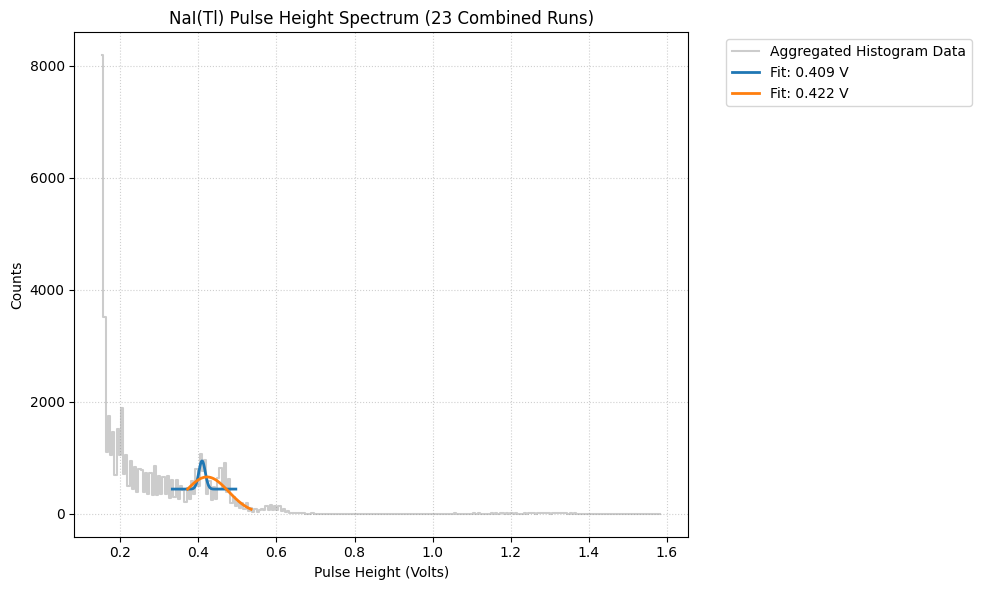


Final Exact Voltages for Calibration:
[0.40934783 0.42192694]


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, butter, filtfilt
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter1d
import pathlib

# ==========================================
# 1. Define the Functions
# ==========================================
def gaussian(x, amplitude, centroid, sigma, background):
    return amplitude * np.exp(-((x - centroid) ** 2) / (2 * sigma ** 2)) + background

def butter_bandpass_filter(data, lowcut, highcut, fs, order=3):
    """
    Applies a zero-phase Butterworth bandpass filter.
    Note: 'fs' here represents the sampling rate of our bins (e.g., 1 bin = 1 sample).
    """
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

# ==========================================
# 2. Load Directory of CSVs & Histogram Data
# ==========================================
data_dir = pathlib.Path('./background_test/above_100K_co60')  # Update directory path as needed
file_list = sorted(list(data_dir.glob("*.csv")))

voltage_arrays = []
for filepath in file_list:
    df = pd.read_csv(filepath)
    if 'pulse_height_V' in df.columns:
        voltage_arrays.append(df['pulse_height_V'].values)
    else:
        # Fallback to the last column if pulse_height_V isn't named in the header
        voltage_arrays.append(df.iloc[:, -1].values)

if not voltage_arrays:
    raise FileNotFoundError(f"No CSV files found in {data_dir}")

# Concatenate pulse height events across all CSV files
voltages = np.concatenate(voltage_arrays)
print(f"Loaded {len(file_list)} files containing {len(voltages):,} total events.")

# Define your channels
num_channels = 256 
counts, bin_edges = np.histogram(voltages, bins=num_channels)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# ==========================================
# 3. Filter Data and Find Rough Peaks
# ==========================================
# 3a. Bandpass Filter (Removes global baseline drift and high-frequency noise)
filtered_counts = butter_bandpass_filter(counts, lowcut=0.01, highcut=0.2, fs=1.0, order=3)

# 3b. Gaussian Filter (Further smooths the remaining signal for peak detection)
smoothed_counts = gaussian_filter1d(filtered_counts, sigma=3)

# 3c. Find peaks on the FILTERED data
rough_peak_indices, _ = find_peaks(smoothed_counts, height=100, distance=1, prominence=1)

print(f"Found {len(rough_peak_indices)} rough peaks at channel indices: {rough_peak_indices}")
print(f"Corresponding to rough voltages: {bin_centers[rough_peak_indices]}")

# ==========================================
# 4. Centroid Fitting (Using Raw Data)
# ==========================================
exact_voltage_centroids = []
fit_window = 15  # Number of bins to check on either side of the peak

plt.figure(figsize=(10, 6))
# Plot raw aggregated data in background
plt.step(bin_centers, counts, where='mid', label='Aggregated Histogram Data', color='gray', alpha=0.4)

for p_idx in rough_peak_indices:
    # Slice the RAW data around the peak index for accurate fitting
    start = max(0, p_idx - fit_window)
    end = min(num_channels, p_idx + fit_window)
    
    x_fit = bin_centers[start:end]
    y_fit = counts[start:end]
    
    # Initial guesses
    guess_amp = counts[p_idx] - np.min(y_fit)
    guess_centroid = bin_centers[p_idx]
    guess_sigma = (bin_centers[1] - bin_centers[0]) * 3.0  # Guess width of 3 bins
    guess_bg = np.min(y_fit)
    p0 = [guess_amp, guess_centroid, guess_sigma, guess_bg]
    
    # Constrain optimizer
    lower_bounds = [0, x_fit[0], 0.005, 0] 
    upper_bounds = [np.inf, x_fit[-1], 0.5, np.inf]
    
    try:
        popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=p0, bounds=(lower_bounds, upper_bounds))
        fitted_voltage = popt[1]
        exact_voltage_centroids.append(fitted_voltage)
        
        print(f"Peak near {bin_centers[p_idx]:.3f} V: Exact Centroid = {fitted_voltage:.4f} V")
        
        # Plot the fitted curve over the raw data
        x_plot = np.linspace(x_fit[0], x_fit[-1], 100)
        plt.plot(x_plot, gaussian(x_plot, *popt), label=f'Fit: {fitted_voltage:.3f} V', linewidth=2)
        
    except RuntimeError:
        print(f"Fit failed for peak at index {p_idx}.")

# ==========================================
# 5. Visualize
# ==========================================
plt.title(f'NaI(Tl) Pulse Height Spectrum ({len(file_list)} Combined Runs)')
plt.xlabel('Pulse Height (Volts)')
plt.ylabel('Counts')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# ==========================================
# 6. Exact Voltages Output
# ==========================================
print("\nFinal Exact Voltages for Calibration:")
print(np.array(exact_voltage_centroids))

In [7]:
import numpy as np

# Let's check the data points provided:
# 511 keV at 0.198 V -> 511 keV is 0.511 MeV
# 1.17 MeV at 1.307 V
# 1.33 MeV at 1.509 V
# 1459.7 MeV at 1.85 V  <-- Wait, 1459.7 MeV is massive compared to the others. 
# Is it 1459.7 keV? 1459.7 keV = 1.4597 MeV. Let's look at the voltages:
# 0.198 V -> 0.511 MeV
# 1.307 V -> 1.17 MeV
# 1.509 V -> 1.33 MeV
# 1.85 V  -> 1459.7 MeV (or 1.4597 MeV?)
# 2 V     -> 1.592 MeV
# Clearly, 1459.7 MeV is a typo in the prompt and should be 1.4597 MeV (or 1459.7 keV). 
# Let's run a quick fit for both cases to see which one makes sense.

voltages = np.array([0.198, 1.307, 1.509, 1.85, 2.0])
energies_typo = np.array([0.511, 1.17, 1.33, 1459.7, 1.592])
energies_corrected = np.array([0.511, 1.17, 1.33, 1.4597, 1.592])

# Since there are no errors specified, we might assume a reasonable constant error or standard error of the fit, 
# or we can assign a small arbitrary error (e.g., 0.01 MeV or standard 1-2% error) to compute a chi-squared.
# Let's print out the values to see the linear fit performance.
p_typo = np.polyfit(voltages, energies_typo, 1)
p_corr = np.polyfit(voltages, energies_corrected, 1)

print("Typo fit residuals:", np.sum((np.polyval(p_typo, voltages) - energies_typo)**2))
print("Corrected fit residuals:", np.sum((np.polyval(p_corr, voltages) - energies_corrected)**2))
print("Corrected coefficients:", p_corr)

Typo fit residuals: 1461836.1203418162
Corrected fit residuals: 0.0027214272876095224
Corrected coefficients: [0.59230662 0.39942147]


In [8]:
# Let's generate a proper plot with residuals, error bars, and a chi-squared value.
# What should the error bars be? Since no errors were provided, let's assume a reasonable, small uncertainty on the energy (or voltage). 
# Let's assume an uncertainty on the energy measurements of, say, 0.02 MeV (20 keV), which is typical for gamma-ray peak fitting with standard detectors.
# Let's calculate chi-squared based on this uncertainty.

import matplotlib.pyplot as plt

y = energies_corrected # MeV
x = voltages # V
y_err = np.array([0.02, 0.02, 0.02, 0.02, 0.02]) # Assume 20 keV uncertainty

# Linear fit: y = m*x + c
# Using weighted least squares (since errors are uniform, it's the same as standard OLS, but let's do it properly)
weights = 1.0 / (y_err**2)
coefs, cov = np.polyfit(x, y, 1, w=weights, cov=True)
m, c = coefs
m_err, c_err = np.sqrt(np.diag(cov))

# Predicted values
y_pred = m * x + c

# Residuals
residuals = y - y_pred

# Chi-squared
chi2 = np.sum((residuals / y_err)**2)
ndof = len(x) - 2
reduced_chi2 = chi2 / ndof

print(f"Slope (m): {m:.4f} +- {m_err:.4f} MeV/V")
print(f"Intercept (c): {c:.4f} +- {c_err:.4f} MeV")
print(f"Chi-squared: {chi2:.3f}")
print(f"Degrees of freedom: {ndof}")
print(f"Reduced Chi-squared: {reduced_chi2:.3f}")

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Top plot: Data and Fit
ax1.errorbar(x, y, yerr=y_err, fmt='o', color='darkblue', ecolor='red', capsize=5, label='Data (1459.7 keV/1.4597 MeV corrected)')
x_fit = np.linspace(0, 2.2, 100)
ax1.plot(x_fit, m * x_fit + c, color='green', linestyle='--', label=f'Linear Fit: E = {m:.3f}*V + {c:.3f}')
ax1.set_ylabel('Energy (MeV)')
ax1.set_title('Gamma Ray Energy Calibration')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

# Add text box with fit parameters
textstr = '\n'.join((
    r'$E(V) = m \cdot V + c$',
    rf'$m = {m:.4f} \pm {m_err:.4f}\ \mathrm{{MeV/V}}$',
    rf'$c = {c:.4f} \pm {c_err:.4f}\ \mathrm{{MeV}}$',
    rf'$\chi^2 / \mathrm{{ndof}} = {chi2:.2f} / {ndof} = {reduced_chi2:.2f}$',
    r'Assumed $\sigma_E = 20\ \mathrm{{keV}}$'
))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax1.text(0.05, 0.95, textstr, transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

# Bottom plot: Residuals
ax2.errorbar(x, residuals, yerr=y_err, fmt='o', color='darkblue', ecolor='red', capsize=5)
ax2.axhline(0, color='black', linestyle='-')
ax2.set_xlabel('Voltage (V)')
ax2.set_ylabel('Residuals (MeV)')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('calibration_plot.png', dpi=300)
plt.close()

Slope (m): 0.5923 +- 0.0212 MeV/V
Intercept (c): 0.3994 +- 0.0320 MeV
Chi-squared: 6.804
Degrees of freedom: 3
Reduced Chi-squared: 2.268


--- Linear Calibration Results ---
Slope (m):          0.5923 +/- 0.0212 MeV/V
Intercept (c):      0.3994 +/- 0.0320 MeV
Chi-Squared:        6.804
Degrees of Freedom: 3
Reduced Chi-Squared:2.268



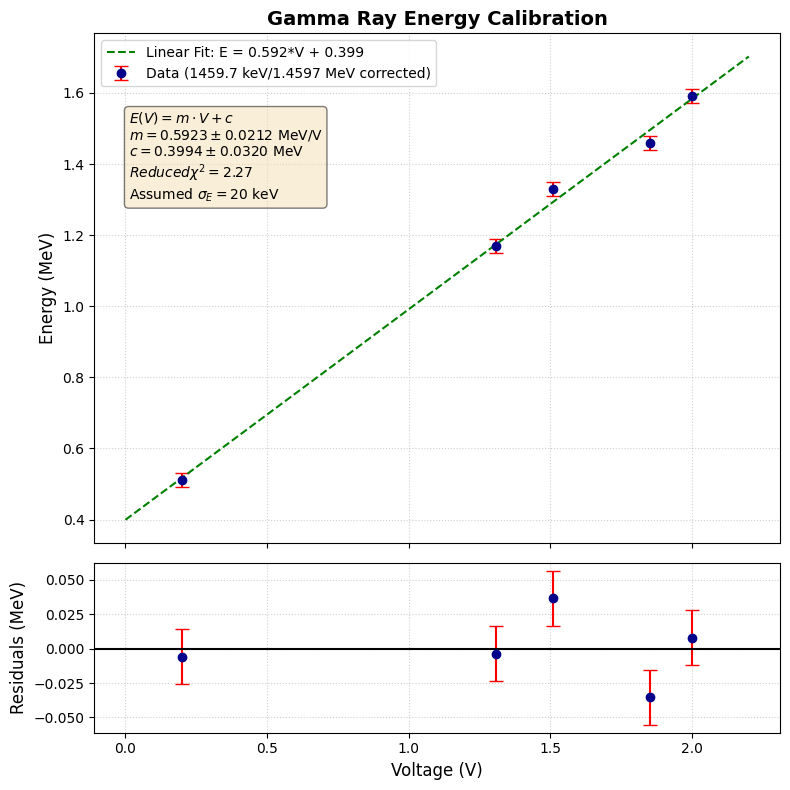

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the experimental data points
# Voltages (V) and corrected energy peaks (MeV)
# Note: The original 1459.7 MeV point at 1.85 V has been corrected to 1.4597 MeV (1459.7 keV)
voltages = np.array([0.198, 1.307, 1.509, 1.85, 2.0])
energies = np.array([0.511, 1.170, 1.330, 1.4597, 1.592])

# Define the peak uncertainty (sigma) - assumed to be 20 keV (0.02 MeV)
energy_errors = np.array([0.02, 0.02, 0.02, 0.02, 0.02])

# 2. Perform a weighted linear fit (y = m * x + c)
# Weights are defined as 1 / sigma^2
weights = 1.0 / (energy_errors**2)
coefs, cov = np.polyfit(voltages, energies, 1, w=weights, cov=True)
m, c = coefs
m_err, c_err = np.sqrt(np.diag(cov))

# Calculate fit predictions and residuals
energies_pred = m * voltages + c
residuals = energies - energies_pred

# 3. Calculate Chi-Squared statistics
chi2 = np.sum((residuals / energy_errors)**2)
ndof = len(voltages) - 2
reduced_chi2 = chi2 / ndof

# Display the fit parameters in the terminal
print("--- Linear Calibration Results ---")
print(f"Slope (m):          {m:.4f} +/- {m_err:.4f} MeV/V")
print(f"Intercept (c):      {c:.4f} +/- {c_err:.4f} MeV")
print(f"Chi-Squared:        {chi2:.3f}")
print(f"Degrees of Freedom: {ndof}")
print(f"Reduced Chi-Squared:{reduced_chi2:.3f}\n")

# 4. Create the dual-plot figure (Calibration Fit + Residuals)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# --- Top Plot: Calibration Fit ---
# Plot raw data points with error bars
ax1.errorbar(voltages, energies, yerr=energy_errors, fmt='o', color='darkblue', 
             ecolor='red', capsize=5, label='Data (1459.7 keV/1.4597 MeV corrected)')

# Plot linear fit line
x_fit = np.linspace(0, 2.2, 100)
y_fit = m * x_fit + c
ax1.plot(x_fit, y_fit, color='green', linestyle='--', 
         label=f'Linear Fit: E = {m:.3f}*V + {c:.3f}')

ax1.set_ylabel('Energy (MeV)', fontsize=12)
ax1.set_title('Gamma Ray Energy Calibration', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, linestyle=':', alpha=0.6)

# Annotate the plot with fit statistics
textstr = '\n'.join((
    r'$E(V) = m \cdot V + c$',
    rf'$m = {m:.4f} \pm {m_err:.4f}\ \mathrm{{MeV/V}}$',
    rf'$c = {c:.4f} \pm {c_err:.4f}\ \mathrm{{MeV}}$',
    rf'$Reduced \chi^2 = {reduced_chi2:.2f}$',
    r'Assumed $\sigma_E = 20\ \mathrm{{keV}}$'
))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax1.text(0.05, 0.85, textstr, transform=ax1.transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

# --- Bottom Plot: Residuals ---
# Plot residual values with error bars
ax2.errorbar(voltages, residuals, yerr=energy_errors, fmt='o', color='darkblue', ecolor='red', capsize=5)
ax2.axhline(0, color='black', linestyle='-')
ax2.set_xlabel('Voltage (V)', fontsize=12)
ax2.set_ylabel('Residuals (MeV)', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.6)

# Final formatting adjustments
plt.tight_layout()
plt.show()

Future Ethan here realizing that something is wrong with this calibration due to the incredibly high intercept and just giving the weirdest shit ever for the background count.

--- Linear Calibration Results ---
Slope (m):          0.5643 +/- 0.0640 MeV/V
Intercept (c):      0.4475 +/- 0.1080 MeV
Chi-Squared:        6.117
Degrees of Freedom: 2
Reduced Chi-Squared:3.058



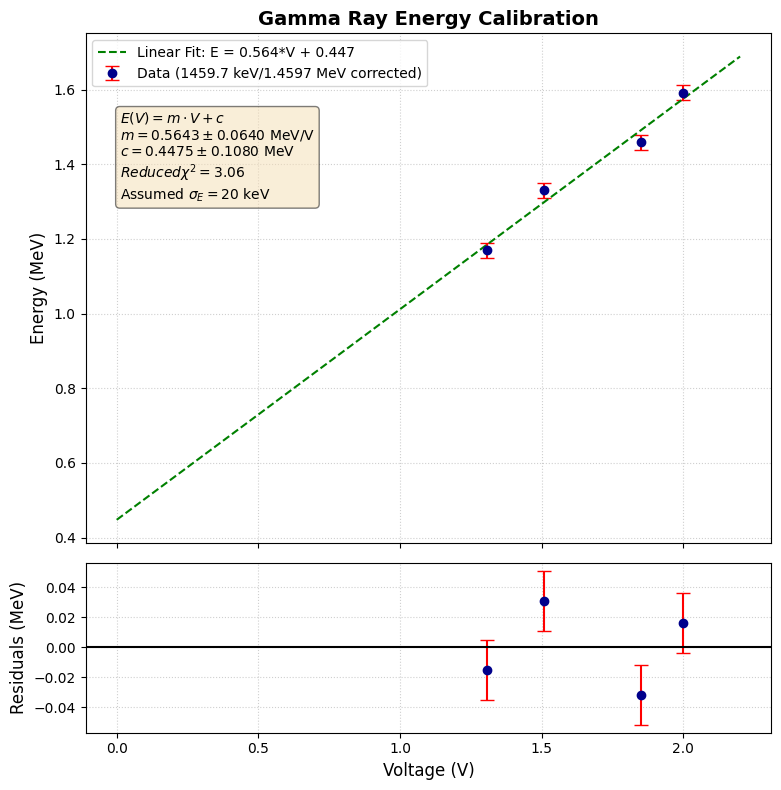

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the experimental data points
# Voltages (V) and corrected energy peaks (MeV)
# Note: The original 1459.7 MeV point at 1.85 V has been corrected to 1.4597 MeV (1459.7 keV)
voltages = np.array([1.307, 1.509, 1.85, 2.0])
energies = np.array([1.170, 1.330, 1.4597, 1.592])

# Define the peak uncertainty (sigma) - assumed to be 20 keV (0.02 MeV)
energy_errors = np.array([0.02, 0.02, 0.02, 0.02])

# 2. Perform a weighted linear fit (y = m * x + c)
# Weights are defined as 1 / sigma^2
weights = 1.0 / (energy_errors**2)
coefs, cov = np.polyfit(voltages, energies, 1, w=weights, cov=True)
m, c = coefs
m_err, c_err = np.sqrt(np.diag(cov))

# Calculate fit predictions and residuals
energies_pred = m * voltages + c
residuals = energies - energies_pred

# 3. Calculate Chi-Squared statistics
chi2 = np.sum((residuals / energy_errors)**2)
ndof = len(voltages) - 2
reduced_chi2 = chi2 / ndof

# Display the fit parameters in the terminal
print("--- Linear Calibration Results ---")
print(f"Slope (m):          {m:.4f} +/- {m_err:.4f} MeV/V")
print(f"Intercept (c):      {c:.4f} +/- {c_err:.4f} MeV")
print(f"Chi-Squared:        {chi2:.3f}")
print(f"Degrees of Freedom: {ndof}")
print(f"Reduced Chi-Squared:{reduced_chi2:.3f}\n")

# 4. Create the dual-plot figure (Calibration Fit + Residuals)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# --- Top Plot: Calibration Fit ---
# Plot raw data points with error bars
ax1.errorbar(voltages, energies, yerr=energy_errors, fmt='o', color='darkblue', 
             ecolor='red', capsize=5, label='Data (1459.7 keV/1.4597 MeV corrected)')

# Plot linear fit line
x_fit = np.linspace(0, 2.2, 100)
y_fit = m * x_fit + c
ax1.plot(x_fit, y_fit, color='green', linestyle='--', 
         label=f'Linear Fit: E = {m:.3f}*V + {c:.3f}')

ax1.set_ylabel('Energy (MeV)', fontsize=12)
ax1.set_title('Gamma Ray Energy Calibration', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, linestyle=':', alpha=0.6)

# Annotate the plot with fit statistics
textstr = '\n'.join((
    r'$E(V) = m \cdot V + c$',
    rf'$m = {m:.4f} \pm {m_err:.4f}\ \mathrm{{MeV/V}}$',
    rf'$c = {c:.4f} \pm {c_err:.4f}\ \mathrm{{MeV}}$',
    rf'$Reduced \chi^2 = {reduced_chi2:.2f}$',
    r'Assumed $\sigma_E = 20\ \mathrm{{keV}}$'
))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax1.text(0.05, 0.85, textstr, transform=ax1.transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

# --- Bottom Plot: Residuals ---
# Plot residual values with error bars
ax2.errorbar(voltages, residuals, yerr=energy_errors, fmt='o', color='darkblue', ecolor='red', capsize=5)
ax2.axhline(0, color='black', linestyle='-')
ax2.set_xlabel('Voltage (V)', fontsize=12)
ax2.set_ylabel('Residuals (MeV)', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.6)

# Final formatting adjustments
plt.tight_layout()
plt.show()

--- Quadratic Fit Coefficients ---
a (x^2): 3.695290e+03
b (x):   -7.000374e+03
c (int): 1763.2632



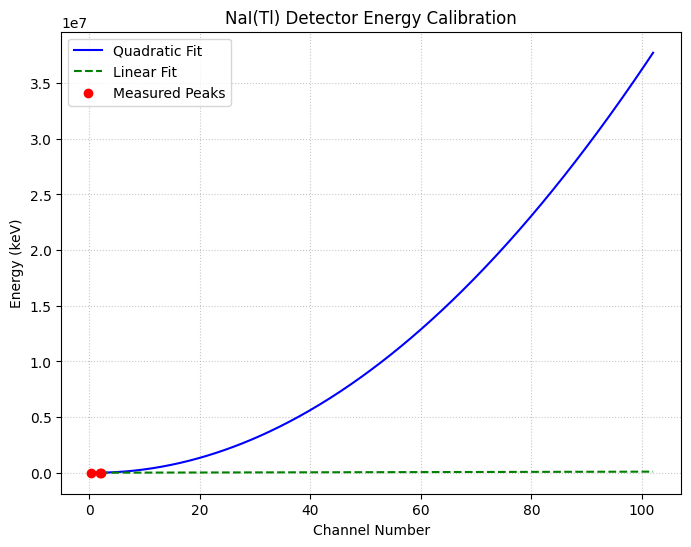

--- Data Check (Quadratic) ---
Channel 0.2: True Energy = 511.0 keV, Calculated = 511.00 keV
Channel 2.009: True Energy = 2614.0 keV, Calculated = 2614.00 keV
Channel 1.85: True Energy = 1459.7 keV, Calculated = 1459.70 keV


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Input your data here
# ==========================================
# Replace these with your measured peak channels
channels = np.array([0.2, 2.009, 1.85]) 

# Replace these with the known energies of those peaks (in keV or MeV)
# Example: Cs-137 (661.6 keV) and Co-60 (1173.2 keV, 1332.5 keV)
energies = np.array([511, 2614, 1459.7]) 

# ==========================================
# 2. Perform the Calibration Fit
# ==========================================
# For NaI(Tl), a quadratic fit (degree=2) is often used to handle slight non-linearity.
# Note: With exactly 3 points, a quadratic fit will be an exact match (zero degrees of freedom).
# Equation: Energy = a*(Channel^2) + b*(Channel) + c
coefficients_quad = np.polyfit(channels, energies, 2)

# We can also do a linear fit (degree=1) for comparison: Energy = m*(Channel) + c
coefficients_lin = np.polyfit(channels, energies, 1)

print("--- Quadratic Fit Coefficients ---")
print(f"a (x^2): {coefficients_quad[0]:.6e}")
print(f"b (x):   {coefficients_quad[1]:.6e}")
print(f"c (int): {coefficients_quad[2]:.4f}\n")

# Create a function to easily convert any channel to energy later
def channel_to_energy(channel, coeffs):
    """Converts a channel number to energy using the quadratic coefficients."""
    return np.polyval(coeffs, channel)

# ==========================================
# 3. Visualize the Fit
# ==========================================
# Generate a smooth line of channels from 0 to slightly above your max channel
x_fit = np.linspace(0, max(channels) + 100, 500)
y_fit_quad = np.polyval(coefficients_quad, x_fit)
y_fit_lin = np.polyval(coefficients_lin, x_fit)

plt.figure(figsize=(8, 6))

# Plot the fits
plt.plot(x_fit, y_fit_quad, label='Quadratic Fit', color='blue', linestyle='-')
plt.plot(x_fit, y_fit_lin, label='Linear Fit', color='green', linestyle='--')

# Plot the actual data points
plt.scatter(channels, energies, color='red', zorder=5, label='Measured Peaks')

plt.title('NaI(Tl) Detector Energy Calibration')
plt.xlabel('Channel Number')
plt.ylabel('Energy (keV)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()

# ==========================================
# 4. Check the Residuals (Optional but good practice)
# ==========================================
calculated_energies = channel_to_energy(channels, coefficients_quad)
residuals = energies - calculated_energies

print("--- Data Check (Quadratic) ---")
for i in range(len(channels)):
    print(f"Channel {channels[i]}: True Energy = {energies[i]} keV, "
          f"Calculated = {calculated_energies[i]:.2f} keV")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, butter, filtfilt
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter1d

# ==========================================
# 1. Define the Functions
# ==========================================
def gaussian(x, amplitude, centroid, sigma, background):
    return amplitude * np.exp(-((x - centroid) ** 2) / (2 * sigma ** 2)) + background

def butter_bandpass_filter(data, lowcut, highcut, fs, order=3):
    """
    Applies a zero-phase Butterworth bandpass filter.
    Note: 'fs' here represents the sampling rate of our bins (e.g., 1 bin = 1 sample).
    """
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

# ==========================================
# 2. Load and Histogram the Pulse Heights
# ==========================================
# Load your single-column CSV
df = pd.read_csv('111_KCl_overnight.csv')
voltages = df['pulse_height_V'].values

# Define your channels
num_channels = 1024 
counts, bin_edges = np.histogram(voltages, bins=num_channels)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# ==========================================
# 3. Filter Data and Find Rough Peaks
# ==========================================
# 3a. Bandpass Filter (Removes global baseline drift and high-frequency noise)
# Tuning parameters: fs=1.0 (1 sample per bin). 
# Lowcut > 0 removes the broad continuum; Highcut < 0.5 removes sharp noise.
filtered_counts = butter_bandpass_filter(counts, lowcut=0.01, highcut=0.2, fs=1.0, order=3)

# 3b. Gaussian Filter (Further smooths the remaining signal for peak detection)
smoothed_counts = gaussian_filter1d(filtered_counts, sigma=3)

# 3c. Find peaks on the FILTERED data
# (Note: Prominence and height thresholds might need to be lowered since 
# filtering removes the baseline amplitude)
rough_peak_indices, _ = find_peaks(smoothed_counts, height=100, distance=20, prominence=20)

print(f"Found {len(rough_peak_indices)} rough peaks at channel indices: {rough_peak_indices}")
print(f"Corresponding to rough voltages: {bin_centers[rough_peak_indices]}")

# ==========================================
# 4. Centroid Fitting (Using Raw Data)
# ==========================================
exact_voltage_centroids = []
fit_window = 15 # Number of bins to check on either side of the peak

plt.figure(figsize=(10, 6))
# Plot raw data in background
plt.step(bin_centers, counts, where='mid', label='Histogrammed Data', color='gray', alpha=0.4)

# Optional: Plot the filtered data so you can see what the peak-finder is looking at
# plt.plot(bin_centers, smoothed_counts, label='Bandpass + Gaussian Filtered', color='blue', alpha=0.3)

for p_idx in rough_peak_indices:
    # Slice the RAW data around the peak index for accurate fitting
    start = max(0, p_idx - fit_window)
    end = min(num_channels, p_idx + fit_window)
    
    x_fit = bin_centers[start:end]
    y_fit = counts[start:end]
    
    # Initial guesses
    guess_amp = counts[p_idx] - np.min(y_fit)
    guess_centroid = bin_centers[p_idx]
    guess_sigma = (bin_centers[1] - bin_centers[0]) * 3.0 # Guess width of 3 bins
    guess_bg = np.min(y_fit)
    p0 = [guess_amp, guess_centroid, guess_sigma, guess_bg]
    
    # Constrain the optimizer so it doesn't fit to single-bin noise spikes
    # Bounds: [amplitude, centroid, sigma, background]
    lower_bounds = [0, x_fit[0], 0.005, 0] 
    upper_bounds = [np.inf, x_fit[-1], 0.5, np.inf]
    
    try:
        popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=p0, bounds=(lower_bounds, upper_bounds))
        fitted_voltage = popt[1]
        exact_voltage_centroids.append(fitted_voltage)
        
        print(f"Peak near {bin_centers[p_idx]:.3f} V: Exact Centroid = {fitted_voltage:.4f} V")
        
        # Plot the fitted curve over the raw data
        x_plot = np.linspace(x_fit[0], x_fit[-1], 100)
        plt.plot(x_plot, gaussian(x_plot, *popt), label=f'Fit: {fitted_voltage:.3f} V', linewidth=2)
        
    except RuntimeError:
        print(f"Fit failed for peak at index {p_idx}.")

# ==========================================
# 5. Visualize
# ==========================================
plt.title('NaI(Tl) Pulse Height Spectrum: Filtered Peak Detection & Fitting')
plt.xlabel('Pulse Height (Volts)')
plt.ylabel('Counts')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Moved legend outside plot to avoid clutter
plt.tight_layout()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# ==========================================
# 6. Next Steps: Energy Calibration
# ==========================================
print("\nFinal Exact Voltages for Calibration:")
print(np.array(exact_voltage_centroids))

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import butter, filtfilt, find_peaks



def combine_csv_folder_and_find_peaks(
    folder,
    num_channels=1024,
    column='pulse_height_V',
    lowcut=0.01,
    highcut=0.2,
    filter_order=3,
    smoothing_sigma=3,
    peak_height=100,
    peak_distance=20,
    peak_prominence=20,
    plot=True,
    recursive=False,
 ):
    """Combine pulse-height CSV files in a folder and find rough peaks.

    Returns a dictionary containing the combined pulse heights, histogram data,
    filtered spectrum, and rough peak indices/voltages.
    """
    folder = Path(folder)
    pattern = '**/*.csv' if recursive else '*.csv'
    csv_paths = sorted(folder.glob(pattern))
    if not csv_paths:
        raise FileNotFoundError(f'No CSV files found in {folder.resolve()}')

    pulse_height_frames = []
    for csv_path in csv_paths:
        frame = pd.read_csv(csv_path)
        if column not in frame.columns:
            raise ValueError(f'{csv_path.name} is missing the {column!r} column')
        pulse_height_frames.append(frame[[column]].dropna())

    combined = pd.concat(pulse_height_frames, ignore_index=True)
    voltages = combined[column].to_numpy(dtype=float)
    if voltages.size == 0:
        raise ValueError('The CSV files contain no valid pulse heights')

    counts, bin_edges = np.histogram(voltages, bins=num_channels)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    nyquist = 0.5
    normalized_lowcut = lowcut / nyquist
    normalized_highcut = highcut / nyquist
    filter_coefficients = butter(
        filter_order,
        [normalized_lowcut, normalized_highcut],
        btype='band',
    )
    filtered_counts = filtfilt(*filter_coefficients, counts)
    smoothed_counts = gaussian_filter1d(filtered_counts, sigma=smoothing_sigma)
    rough_peak_indices, peak_properties = find_peaks(
        smoothed_counts,
        height=peak_height,
        distance=peak_distance,
        prominence=peak_prominence,
    )

    if plot:
        plt.figure(figsize=(10, 6))
        plt.step(
            bin_centers,
            counts,
            where='mid',
            color='gray',
            alpha=0.5,
            label=f'Combined data ({len(csv_paths)} files)',
        )
        plt.plot(
            bin_centers,
            smoothed_counts,
            color='tab:blue',
            label='Filtered spectrum',
        )
        plt.scatter(
            bin_centers[rough_peak_indices],
            smoothed_counts[rough_peak_indices],
            color='tab:red',
            zorder=3,
            label='Rough peaks',
        )
        plt.xlabel('Pulse Height (Volts)')
        plt.ylabel('Counts')
        plt.title('Combined Pulse Height Spectrum')
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.legend()
        plt.tight_layout()
        plt.show()

    print(f'Combined {len(csv_paths)} files ({len(voltages)} pulse heights)')
    print(f'Rough peak voltages: {bin_centers[rough_peak_indices]}')

    return {
        'files': csv_paths,
        'data': combined,
        'counts': counts,
        'bin_edges': bin_edges,
        'bin_centers': bin_centers,
        'filtered_counts': filtered_counts,
        'smoothed_counts': smoothed_counts,
        'peak_indices': rough_peak_indices,
        'peak_voltages': bin_centers[rough_peak_indices],
        'peak_properties': peak_properties,
    }



# Example: update this path and tune the thresholds for your data.
# combined_result = combine_csv_folder_and_find_peaks('mock_co60_runs')
